In [1]:

import numpy as np
import pandas as pd
import os

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
# from scipy.stats import skew

In [2]:
from sklearn.metrics import r2_score
from sklearn import metrics
from sklearn.model_selection import train_test_split
# from sklearn.metrics import accuracy_score,precision_score,recall_score,confusion_matrix
# import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats import weightstats as stests
from scipy import stats
# from numpy import loadtxt
from sklearn.ensemble import RandomForestClassifier,RandomForestRegressor

In [3]:
df_merge_age = pd.read_csv('/content/NHANES_analysis_data.csv')
df_merge_age.shape

(10570, 25)

In [4]:
df_symbol_name = pd.read_csv('/content/Symbol_Name.csv')
df_symbol_name

,Symbol,Name
0,RIDAGEYR,Chronological age
1,LBXGLU,Fasting Glucose
2,LBXWBCSI,Total WBC count
3,LBXLYPCT,Lymphocyte percent
4,LBXMCVSI,Mean Corpuscular Volume
5,LBXRDW,RDW-CV
6,LBXSAL,S.Albumin
7,LBXSAPSI,S.Alkaline Phosphatase
8,LBXSCR,S.Creatinine
9,LBXHSCRP,HS-'C' Reactive Protein


In [5]:
import pandas as pd

# Your original dictionary mapping
biomarkers = {
    0: 'Chronological age',
    1: 'Fasting Glucose',
    2: 'Total WBC count',
    3: 'Lymphocyte percent',
    4: 'Mean Corpuscular Volume',
    5: 'RDW-CV',
    6: 'S.Albumin',
    7: 'S.Alkaline Phosphatase',
    8: 'S.Creatinine',
    9: "HS-'C' Reactive Protein",
    10: 'BodyMassIndex',
    11: 'WaistCircumferece',
    12: 'HDL',
    13: 'LDL',
    14: 'Triglycerides',
    15: 'Total Cholesterol',
    16: 'Fasting Insulin'
}

# Appending adult normal reference ranges and units
reference_data = {
    0: {"Normal Range": "N/A", "Units": "Years"},
    1: {"Normal Range": "70 - 100", "Units": "mg/dL"},
    2: {"Normal Range": "4.0 - 11.0", "Units": "x10^3/µL"},
    3: {"Normal Range": "20.0 - 40.0", "Units": "%"},
    4: {"Normal Range": "80.0 - 100.0", "Units": "fL"},
    5: {"Normal Range": "11.5 - 14.5", "Units": "%"},
    6: {"Normal Range": "3.5 - 5.0", "Units": "g/dL"},
    7: {"Normal Range": "44 - 147", "Units": "U/L"},
    8: {"Normal Range": "0.6 - 1.3", "Units": "mg/dL"},
    9: {"Normal Range": "< 3.0", "Units": "mg/L"},
    10: {"Normal Range": "18.5 - 24.9", "Units": "kg/m²"},
    11: {"Normal Range": "< 102 (Men) / < 88 (Women)", "Units": "cm"},
    12: {"Normal Range": "> 40 (Men) / > 50 (Women)", "Units": "mg/dL"},
    13: {"Normal Range": "< 100", "Units": "mg/dL"},
    14: {"Normal Range": "< 150", "Units": "mg/dL"},
    15: {"Normal Range": "< 200", "Units": "mg/dL"},
    16: {"Normal Range": "2-23", "Units": "µU/mL"}
}

# Constructing the comprehensive DataFrame data
df_data = []
for index, name in biomarkers.items():
    df_data.append({
        "Index": index,
        "Biomarker Name": name,
        "Normal Range": reference_data[index]["Normal Range"],
        "Units": reference_data[index]["Units"]
    })

# Form the DataFrame
df_names_ranges = pd.DataFrame(df_data).set_index("Index").reset_index(drop=True)

# Display the output
df_names_ranges


,Biomarker Name,Normal Range,Units
0,Chronological age,N/A,Years
1,Fasting Glucose,70 - 100,mg/dL
2,Total WBC count,4.0 - 11.0,x10^3/µL
3,Lymphocyte percent,20.0 - 40.0,%
4,Mean Corpuscular Volume,80.0 - 100.0,fL
5,RDW-CV,11.5 - 14.5,%
6,S.Albumin,3.5 - 5.0,g/dL
7,S.Alkaline Phosphatase,44 - 147,U/L
8,S.Creatinine,0.6 - 1.3,mg/dL
9,HS-'C' Reactive Protein,< 3.0,mg/L


In [6]:
# Define the complete BMI classification data
bmi_data = [
    {"Classification": "Underweight",     "BMI Range (kg/m²)" : "< 18.5",      },
    {"Classification": "Normal weight",   "BMI Range (kg/m²)" : "18.5 - 24.9" },
    {"Classification": "Overweight",      "BMI Range (kg/m²)" : "25.0 - 29.9" },
    {"Classification": "Obese (Class 1)", "BMI Range (kg/m²)": "30.0 - 34.9" },
    {"Classification": "Obese (Class 2)", "BMI Range (kg/m²)": "35.0 - 39.9" },
    {"Classification": "Extreme Obese (Class 3)", "BMI Range (kg/m²)": "≥ 40.0" }
]
# Form the DataFrame
bmi_df = pd.DataFrame(bmi_data)
bmi_df

,Classification,BMI Range (kg/m²)
0,Underweight,< 18.5
1,Normal weight,18.5 - 24.9
2,Overweight,25.0 - 29.9
3,Obese (Class 1),30.0 - 34.9
4,Obese (Class 2),35.0 - 39.9
5,Extreme Obese (Class 3),≥ 40.0


In [7]:
df_merge_age.head()

,RIDAGEYR,BMXWT,BMXBMI,BMXWAIST,LBDHDD,LBDLDL,LBXTR,LBXTC,LBXGLU,LBXGH,...,LBXNEPCT,LBXMCVSI,LBXRDW,LBXSAL,LBXSAPSI,LBXSCR,LBXHSCRP,loge_insulin,loge_LBXHSCRP,NLR
0,53,90.4,30.8,107.9,63,173,147.0,265,101,5.5,...,54.8,101.8,13.4,4.5,47,1.05,1.4,2.848392,0.336472,1.739130
1,78,83.4,28.8,116.5,30,145,269.0,229,84,5.8,...,55.8,90.8,14.7,4.5,46,1.12,0.6,2.465554,-0.510826,1.923077
2,42,55.2,20.3,80.4,53,142,47.0,204,84,5.6,...,44.8,87.8,12.3,4.3,46,0.64,0.5,1.690096,-0.693147,0.950000
3,72,64.4,28.6,92.9,78,103,46.0,190,107,5.9,...,56.6,92.6,14.1,4.1,83,1.15,2.5,2.109000,0.916291,1.842105
4,22,76.6,28.0,86.6,48,102,68.0,164,95,5.6,...,39.7,83.2,13.1,4.4,61,0.73,1.3,2.432736,0.262364,1.076923


In [8]:
df_merge_age['logInsulin_range'] = pd.cut(df_merge_age.loge_insulin, [0,1.5,2,2.75,3.5,5])
df_merge_age['BMXBMI_range'] = pd.cut(df_merge_age.BMXBMI, [18.5,25,30,35,45,100],labels=['normal','overweight','obese','extreme obese','morbid obese'])
df_merge_age['BMXWAIST_range'] = pd.qcut(df_merge_age.BMXWAIST, q=5, precision=5)
df_merge_age['BMXWT_range'] = pd.qcut(df_merge_age.BMXWT, q=5, precision=5)
df_merge_age['TGL_range'] = pd.cut(df_merge_age.LBXTR, [0,60,90,160,250,500])
df_merge_age['loge_LBXHSCRP_range'] = pd.qcut(df_merge_age.loge_LBXHSCRP, q=4, precision=5)

In [9]:
df_merge_age.columns

Index(['RIDAGEYR', 'BMXWT', 'BMXBMI', 'BMXWAIST', 'LBDHDD', 'LBDLDL', 'LBXTR',
       'LBXTC', 'LBXGLU', 'LBXGH', 'LBXIN', 'LBXWBCSI', 'LBXLYPCT', 'LBDLYMNO',
       'LBDNENO', 'LBXNEPCT', 'LBXMCVSI', 'LBXRDW', 'LBXSAL', 'LBXSAPSI',
       'LBXSCR', 'LBXHSCRP', 'loge_insulin', 'loge_LBXHSCRP', 'NLR',
       'logInsulin_range', 'BMXBMI_range', 'BMXWAIST_range', 'BMXWT_range',
       'TGL_range', 'loge_LBXHSCRP_range'],
      dtype='object')

### Correlation Analysis - Note: Samples with Body Mass Index in Normal range





In [10]:
from scipy.stats import pearsonr

# 2. Define target column and comparison columns
target_col = 'LBDHDD'
compare_cols = ['BMXBMI','BMXWT','BMXWAIST','loge_insulin','loge_LBXHSCRP','LBXTR','LBXGH','LBDLDL','LBXWBCSI','LBXSAPSI', 'LBXSCR','LBXRDW']

# 3. Calculate correlation and p-value for each pair
results = []
for col in compare_cols:
    # pearsonr returns a tuple: (correlation_coefficient, p_value)
    corr, p_val = pearsonr(df_merge_age[(df_merge_age['BMXBMI_range']=='normal') ][target_col], df_merge_age[(df_merge_age['BMXBMI_range']=='normal') ][col])
    results.append({
        'Comparison': f'{target_col} with {col}',
        'Correlation': round(corr, 4),
        'P-Value': round(p_val, 4)
    })

# 4. Display results as a clean DataFrame
results_df = pd.DataFrame(results)
print(results_df)


                   Comparison  Correlation  P-Value
0          LBDHDD with BMXBMI      -0.2015   0.0000
1           LBDHDD with BMXWT      -0.2144   0.0000
2        LBDHDD with BMXWAIST      -0.1901   0.0000
3    LBDHDD with loge_insulin      -0.2417   0.0000
4   LBDHDD with loge_LBXHSCRP      -0.0879   0.0000
5           LBDHDD with LBXTR      -0.3643   0.0000
6           LBDHDD with LBXGH      -0.1340   0.0000
7          LBDHDD with LBDLDL      -0.0158   0.4114
8        LBDHDD with LBXWBCSI      -0.1236   0.0000
9        LBDHDD with LBXSAPSI      -0.1211   0.0000
10         LBDHDD with LBXSCR      -0.0651   0.0007
11         LBDHDD with LBXRDW       0.0323   0.0922


### Correlation Analysis - Body Mass Index in Normal range, age over 40

In [11]:
from scipy.stats import pearsonr

# 2. Define target column and comparison columns
target_col = 'LBDHDD'
compare_cols = ['BMXBMI','BMXWT','BMXWAIST','loge_insulin','loge_LBXHSCRP','LBXTR','LBXGH','LBDLDL','LBXWBCSI','LBXSAPSI', 'LBXSCR','LBXRDW']

# 3. Calculate correlation and p-value for each pair
results = []
for col in compare_cols:
    # pearsonr returns a tuple: (correlation_coefficient, p_value)
    corr, p_val = pearsonr(df_merge_age[(df_merge_age['BMXBMI_range']=='normal')& (df_merge_age['RIDAGEYR']>40) ][target_col], df_merge_age[(df_merge_age['BMXBMI_range']=='normal') & (df_merge_age['RIDAGEYR']>40)][col])
    results.append({
        'Comparison': f'{target_col} with {col}',
        'Correlation': round(corr, 4),
        'P-Value': round(p_val, 4)
    })

# 4. Display results as a clean DataFrame
results_df = pd.DataFrame(results)
print(results_df)


                   Comparison  Correlation  P-Value
0          LBDHDD with BMXBMI      -0.2095   0.0000
1           LBDHDD with BMXWT      -0.1941   0.0000
2        LBDHDD with BMXWAIST      -0.2186   0.0000
3    LBDHDD with loge_insulin      -0.2727   0.0000
4   LBDHDD with loge_LBXHSCRP      -0.1033   0.0000
5           LBDHDD with LBXTR      -0.4171   0.0000
6           LBDHDD with LBXGH      -0.1895   0.0000
7          LBDHDD with LBDLDL      -0.0202   0.4028
8        LBDHDD with LBXWBCSI      -0.1327   0.0000
9        LBDHDD with LBXSAPSI      -0.0963   0.0001
10         LBDHDD with LBXSCR      -0.0618   0.0102
11         LBDHDD with LBXRDW      -0.0134   0.5785


## 2D analysis;
### Body Mass Index in Normal range and Overweight range (to increase sample size)

### Mean values of HDL for different value ranges of  HSCRP and log-insulin

/tmp/ipykernel_2602/1530940753.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df_tgl_sap_glu=pd.pivot_table(df_merge_age[df_merge_age['BMXBMI_range'].isin(['normal','overweight'])],index='loge_LBXHSCRP_range',columns='logInsulin_range',values='LBDHDD',aggfunc='mean')


<Axes: xlabel='logInsulin_range', ylabel='loge_LBXHSCRP_range'>

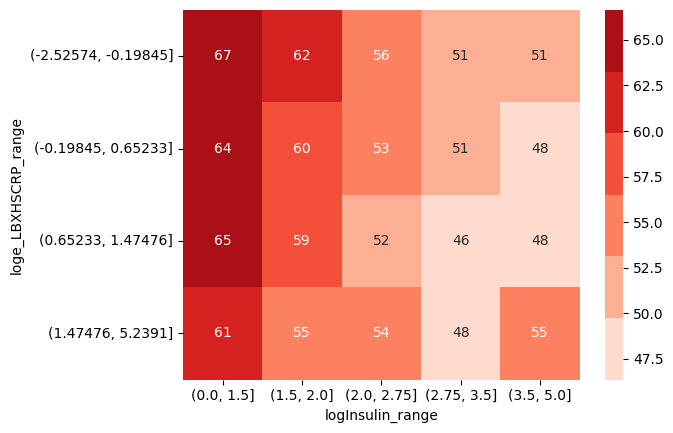

In [12]:
df_tgl_sap_glu=pd.pivot_table(df_merge_age[df_merge_age['BMXBMI_range'].isin(['normal','overweight'])],index='loge_LBXHSCRP_range',columns='logInsulin_range',values='LBDHDD',aggfunc='mean')
colormap = sns.color_palette("Reds")
sns.heatmap(df_tgl_sap_glu,cmap=colormap,annot=True)

#### Total sample count within different value ranges of  HSCRP and log-insulin

/tmp/ipykernel_2602/895128301.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df_tgl_sap_glu=pd.pivot_table(df_merge_age[df_merge_age['BMXBMI_range'].isin(['normal','overweight'])],index='loge_LBXHSCRP_range',columns='logInsulin_range',values='LBDHDD',aggfunc='count')


<Axes: xlabel='logInsulin_range', ylabel='loge_LBXHSCRP_range'>

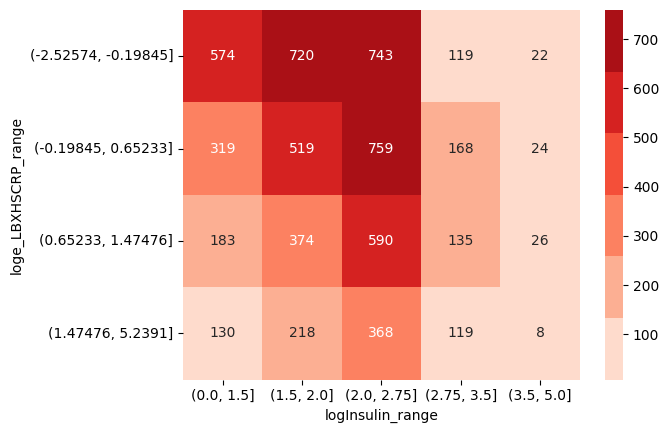

In [13]:
df_tgl_sap_glu=pd.pivot_table(df_merge_age[df_merge_age['BMXBMI_range'].isin(['normal','overweight'])],index='loge_LBXHSCRP_range',columns='logInsulin_range',values='LBDHDD',aggfunc='count')
colormap = sns.color_palette("Reds")
sns.heatmap(df_tgl_sap_glu,cmap=colormap,annot=True,fmt="d")

### Mean values of HDL for different value ranges of  BMXWAIST (cm) and log-insulin

/tmp/ipykernel_2602/2677913296.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df_tgl_sap_glu=pd.pivot_table(df_merge_age[df_merge_age['BMXBMI_range'].isin(['normal','overweight'])],index='BMXWAIST_range',columns='logInsulin_range',values='LBDHDD',aggfunc='mean')


<Axes: xlabel='logInsulin_range', ylabel='BMXWAIST_range'>

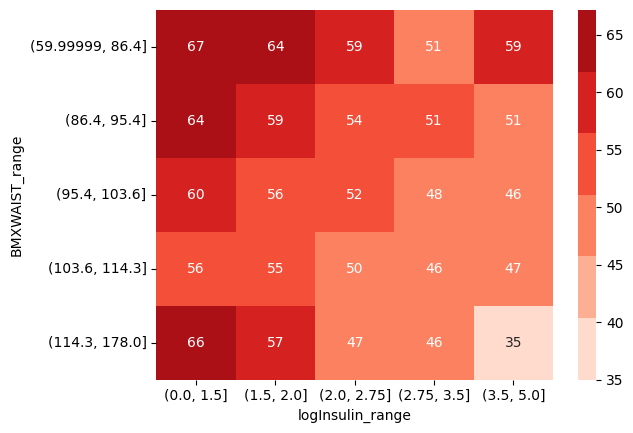

In [14]:
df_tgl_sap_glu=pd.pivot_table(df_merge_age[df_merge_age['BMXBMI_range'].isin(['normal','overweight'])],index='BMXWAIST_range',columns='logInsulin_range',values='LBDHDD',aggfunc='mean')
colormap = sns.color_palette("Reds")
sns.heatmap(df_tgl_sap_glu,cmap=colormap,annot=True)

#### Total sample count within different value ranges of  BMXWAIST (cm) and log-insulin

/tmp/ipykernel_2602/4207063323.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df_tgl_sap_glu=pd.pivot_table(df_merge_age[df_merge_age['BMXBMI_range'].isin(['normal','overweight'])],index='BMXWAIST_range',columns='logInsulin_range',values='LBDHDD',aggfunc='count')


<Axes: xlabel='logInsulin_range', ylabel='BMXWAIST_range'>

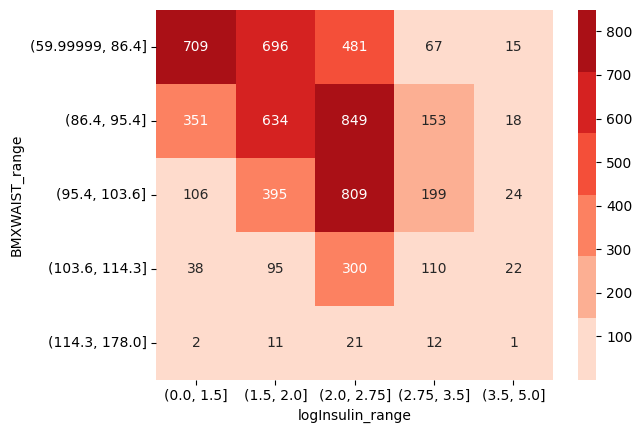

In [15]:
df_tgl_sap_glu=pd.pivot_table(df_merge_age[df_merge_age['BMXBMI_range'].isin(['normal','overweight'])],index='BMXWAIST_range',columns='logInsulin_range',values='LBDHDD',aggfunc='count')
colormap = sns.color_palette("Reds")
sns.heatmap(df_tgl_sap_glu,cmap=colormap,annot=True,fmt="d")

### Mean values of HDL for different value ranges of  BMXWT (Kg) and log-insulin

/tmp/ipykernel_2602/2492319986.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df_tgl_sap_glu=pd.pivot_table(df_merge_age[df_merge_age['BMXBMI_range'].isin(['normal','overweight'])],index='BMXWT_range',columns='logInsulin_range',values='LBDHDD',aggfunc='mean')


<Axes: xlabel='logInsulin_range', ylabel='BMXWT_range'>

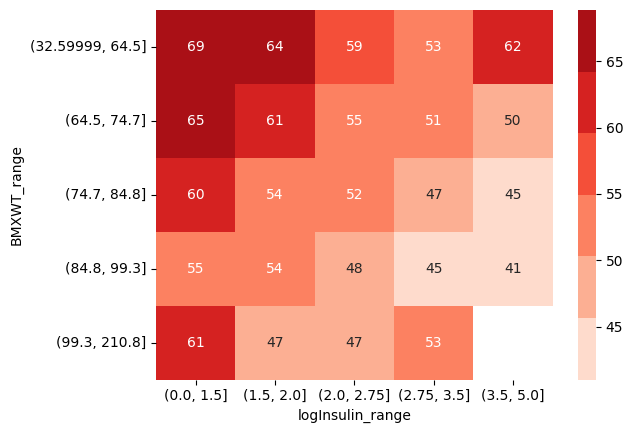

In [16]:
df_tgl_sap_glu=pd.pivot_table(df_merge_age[df_merge_age['BMXBMI_range'].isin(['normal','overweight'])],index='BMXWT_range',columns='logInsulin_range',values='LBDHDD',aggfunc='mean')
colormap = sns.color_palette("Reds")
sns.heatmap(df_tgl_sap_glu,cmap=colormap,annot=True)

#### Total sample count within different value ranges of  BMXWT (Kg) and log-insulin

/tmp/ipykernel_2602/2057003708.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df_tgl_sap_glu=pd.pivot_table(df_merge_age[df_merge_age['BMXBMI_range'].isin(['normal','overweight'])],index='BMXWT_range',columns='logInsulin_range',values='LBDHDD',aggfunc='count')


<Axes: xlabel='logInsulin_range', ylabel='BMXWT_range'>

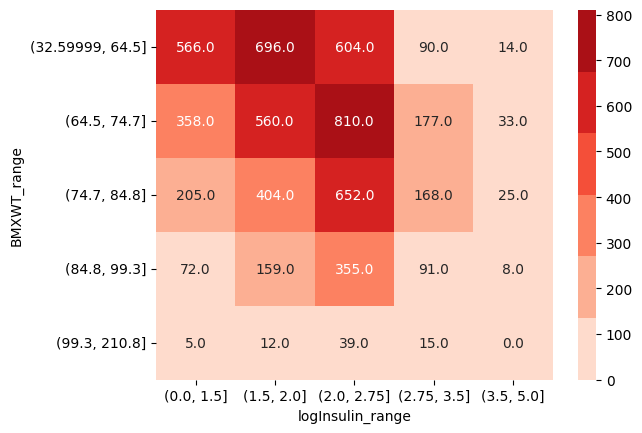

In [17]:
df_tgl_sap_glu=pd.pivot_table(df_merge_age[df_merge_age['BMXBMI_range'].isin(['normal','overweight'])],index='BMXWT_range',columns='logInsulin_range',values='LBDHDD',aggfunc='count')
colormap = sns.color_palette("Reds")
sns.heatmap(df_tgl_sap_glu,cmap=colormap,annot=True,fmt="0.1f")

### Mean values of HDL for different value ranges of  Triglycerides and log-insulin

/tmp/ipykernel_2602/1293799419.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df_tgl_sap_glu=pd.pivot_table(df_merge_age[df_merge_age['BMXBMI_range'].isin(['normal','overweight'])],index='TGL_range',columns='logInsulin_range',values='LBDHDD',aggfunc='mean')


<Axes: xlabel='logInsulin_range', ylabel='TGL_range'>

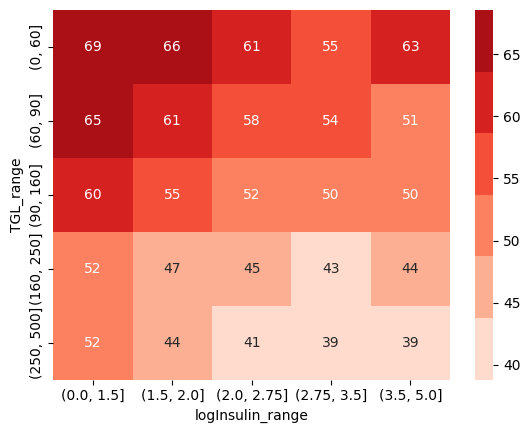

In [18]:
df_tgl_sap_glu=pd.pivot_table(df_merge_age[df_merge_age['BMXBMI_range'].isin(['normal','overweight'])],index='TGL_range',columns='logInsulin_range',values='LBDHDD',aggfunc='mean')
colormap = sns.color_palette("Reds")
sns.heatmap(df_tgl_sap_glu,cmap=colormap,annot=True)

#### Total sample count within different value ranges of  Triglycerides and log-insulin

/tmp/ipykernel_2602/3036217717.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df_tgl_sap_glu=pd.pivot_table(df_merge_age[df_merge_age['BMXBMI_range'].isin(['normal','overweight'])],index='TGL_range',columns='logInsulin_range',values='LBDHDD',aggfunc='count')


<Axes: xlabel='logInsulin_range', ylabel='TGL_range'>

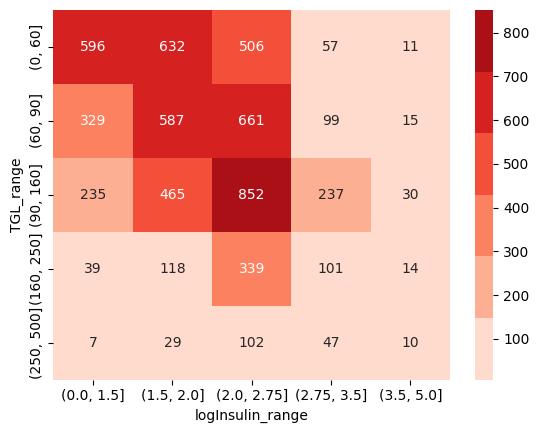

In [19]:
df_tgl_sap_glu=pd.pivot_table(df_merge_age[df_merge_age['BMXBMI_range'].isin(['normal','overweight'])],index='TGL_range',columns='logInsulin_range',values='LBDHDD',aggfunc='count')
colormap = sns.color_palette("Reds")
sns.heatmap(df_tgl_sap_glu,cmap=colormap,annot=True,fmt='d')

### Plots: HDL values with different variable along with linear regression line, R-value, and p-value
#### (BMI in normal range)

#### Body Weight

Text(0.05, 0.95, 'R = -0.21\n$R^2$ = 0.05\np = 0.00')

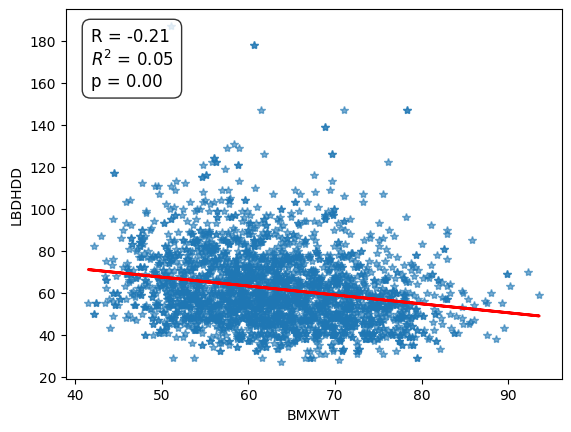

In [20]:
# 1. Clean missing values if necessary (required for linear regression calculation)

xvar = 'BMXWT'
yvar = 'LBDHDD'
df_clean = df_merge_age[df_merge_age['BMXBMI_range']=='normal'][[xvar,yvar]].dropna()
x = df_clean[xvar]
y = df_clean[yvar]
# 2. Calculate the linear regression line, R-value, and p-value
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

# Plot the original scatter points
plt.plot(x, y, "*", label="Data Points", alpha=0.6)

# Plot the overlapping regression line
regression_line = slope * x + intercept
plt.plot(x, regression_line, color="red", linewidth=2, label="Linear Fit")

plt.xlabel(xvar)
plt.ylabel(yvar)

# Format the text box string to include R, R^2, and p-value (to 2 decimal places)
text_box_string = f"R = {r_value:.2f}\n$R^2$ = {r_value**2:.2f}\np = {p_value:.2f}"

plt.gca().text(
    0.05, 0.95, text_box_string,
    transform=plt.gca().transAxes,
    fontsize=12, verticalalignment='top',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8)
)

#### BMI

Text(0.05, 0.95, 'R = -0.20\n$R^2$ = 0.04\np = 0.00')

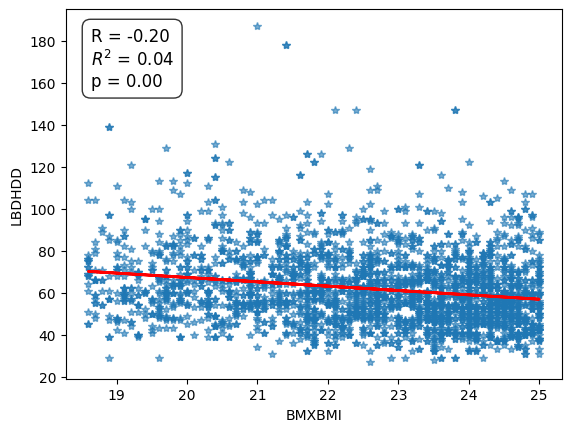

In [21]:
# 1. Clean missing values if necessary (required for linear regression calculation)

xvar = 'BMXBMI'
yvar = 'LBDHDD'
df_clean = df_merge_age[df_merge_age['BMXBMI_range']=='normal'][[xvar,yvar]].dropna()
x = df_clean[xvar]
y = df_clean[yvar]
# 2. Calculate the linear regression line, R-value, and p-value
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

# Plot the original scatter points
plt.plot(x, y, "*", label="Data Points", alpha=0.6)

# Plot the overlapping regression line
regression_line = slope * x + intercept
plt.plot(x, regression_line, color="red", linewidth=2, label="Linear Fit")

plt.xlabel(xvar)
plt.ylabel(yvar)

# Format the text box string to include R, R^2, and p-value (to 2 decimal places)
text_box_string = f"R = {r_value:.2f}\n$R^2$ = {r_value**2:.2f}\np = {p_value:.2f}"

plt.gca().text(
    0.05, 0.95, text_box_string,
    transform=plt.gca().transAxes,
    fontsize=12, verticalalignment='top',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8)
)

## Multilinear fit

In [22]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 2. Separate features (X) and target variable (y)
# Drop the target column to get features; select only the target column for y
df = df_merge_age[(df_merge_age['BMXBMI_range']=='normal') &(df_merge_age['LBDHDD']<100)][['LBDHDD','BMXBMI','BMXWT','BMXWAIST','loge_insulin','loge_LBXHSCRP','LBXTR','LBXGH','LBDLDL','LBXWBCSI','LBXSAPSI', 'LBXSCR','LBXRDW']].dropna()
target_y = 'LBDHDD'
X = df.drop(columns=[target_y])
y = df[target_y]

# 3. Split the dataset into training (80%) and testing sets (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Initialize and fit the Multiple Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# 5. Make predictions on the test data
y_pred = model.predict(X_test)

# 6. Evaluate model performance
print("Model Intercept (b0):", model.intercept_)
print("Model Coefficients (Slopes):", model.coef_)
print("Mean Squared Error (MSE):", mean_squared_error(y_test, y_pred))
print("R-squared Score:", r2_score(y_test, y_pred))
r_squared = r2_score(y_test, y_pred)

Model Intercept (b0): 92.4406424035931
Model Coefficients (Slopes): [ 0.03262286 -0.34479936  0.0735959  -2.69407652 -0.39440677 -0.09141022
 -1.05209495  0.0357751  -0.49157147 -0.02573865 -1.28684657  0.23810295]
Mean Squared Error (MSE): 147.9329071008019
R-squared Score: 0.27663804158772987


In [23]:
np.sqrt(r_squared)

np.float64(0.5259639166214065)

In [24]:
# n is the number of rows in the test set, k is the number of features
n = len(y_test)
k = X_test.shape[1]

# Formula for Adjusted R-squared
adjusted_r_squared = 1 - ((1 - r_squared) * (n - 1) / (n - k - 1))
print(f"Adjusted R-squared: {adjusted_r_squared}")
n,k

Adjusted R-squared: 0.2597830056635605


(528, 12)

In [25]:
np.sqrt(adjusted_r_squared)

np.float64(0.5096891264913943)

In [26]:
df.shape

(2636, 13)

(30.0, 81.0)

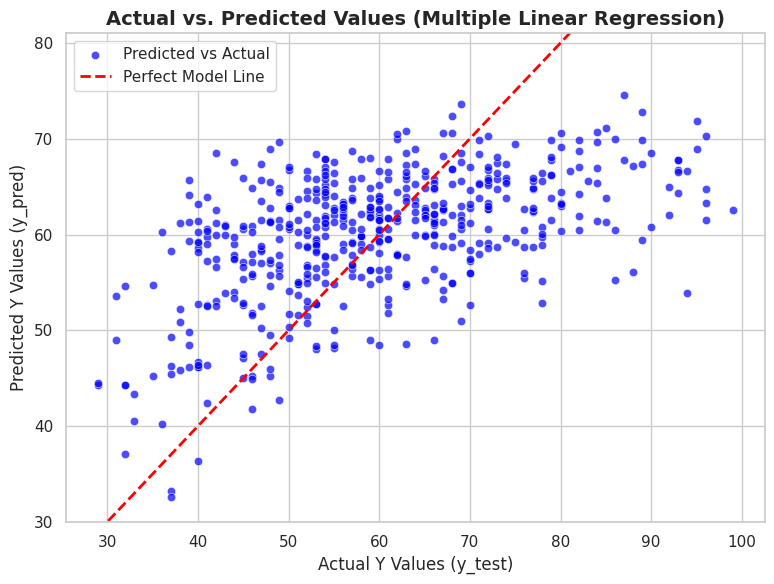

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style of the plot
sns.set_theme(style="whitegrid")

# Create the figure
plt.figure(figsize=(8, 6))

# 1. Plot the actual vs predicted values as a scatter plot
sns.scatterplot(x=y_test, y=y_pred, color="blue", alpha=0.7, label="Predicted vs Actual")

# 2. Add a diagonal reference line (y = x) representing a perfect model
max_val = max(max(y_test), max(y_pred))
min_val = min(min(y_test), min(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", linewidth=2, label="Perfect Model Line")

# 3. Label the chart clearly
plt.title("Actual vs. Predicted Values (Multiple Linear Regression)", fontsize=14, fontweight="bold")
plt.xlabel("Actual Y Values (y_test)", fontsize=12)
plt.ylabel("Predicted Y Values (y_pred)", fontsize=12)
plt.legend(loc="upper left")

# Show the plot
plt.tight_layout()
plt.ylim([30,81])

## Random Forest

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

# 2. Separate features (X) and target variable (y)
# Drop the target column to get features; select only the target column for y
df = df_merge_age[(df_merge_age['BMXBMI_range']=='normal') &(df_merge_age['LBDHDD']<100)][['LBDHDD','BMXBMI','BMXWT','BMXWAIST','loge_insulin','loge_LBXHSCRP','LBXTR','LBXGH','LBDLDL','LBXWBCSI','LBXSAPSI', 'LBXSCR','LBXRDW']].dropna()
target_y = 'LBDHDD'
X = df.drop(columns=[target_y])
y = df[target_y]


# 2. Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize and fit the Random Forest Regressor
# n_estimators determines the number of trees in the forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 4. Generate predictions for the test set and evaluation metrics
y_pred = rf_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(r2,mse)

0.388393650672042 125.07805284090908


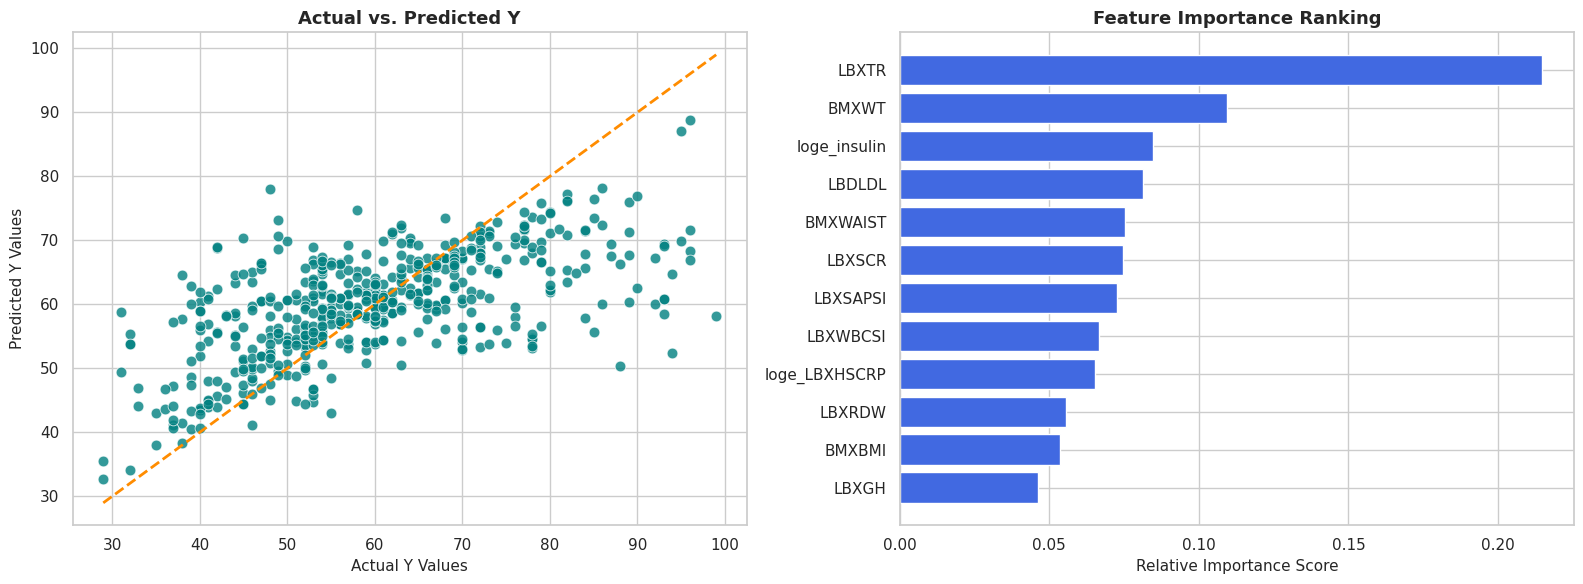

In [29]:
# =====================================================================
# 6. FIXED Evaluation Plots (Bypassing pandas plotting conflict)
# =====================================================================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Actual vs. Predicted (Seaborn)
sns.scatterplot(x=y_test, y=y_pred, ax=axes[0], color="teal", alpha=0.8, s=60)
min_val, max_val = min(min(y_test), min(y_pred)), max(max(y_test), max(y_pred))
axes[0].plot([min_val, max_val], [min_val, max_val], color="darkorange", linestyle="--", linewidth=2)
axes[0].set_title("Actual vs. Predicted Y", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Actual Y Values", fontsize=11)
axes[0].set_ylabel("Predicted Y Values", fontsize=11)

# Plot 2: FIXED Feature Importances (Using pure Matplotlib barh)
importances = rf_model.feature_importances_
# Sort features and names together
indices = np.argsort(importances)
sorted_features = [X.columns[i] for i in indices]
sorted_importances = importances[indices]

# Use axes[1].barh instead of pandas .plot(kind='barh')
axes[1].barh(sorted_features, sorted_importances, color="royalblue")
axes[1].set_title("Feature Importance Ranking", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Relative Importance Score", fontsize=11)

plt.tight_layout()
plt.show()


In [30]:
# 7. Print Performance Summary
print(f"Multi-Feature R-squared Score: {r2_score(y_test, y_pred):.4f}")
print(f"Multi-Feature Mean Squared Error: {mean_squared_error(y_test, y_pred):.4f}")


Multi-Feature R-squared Score: 0.3884
Multi-Feature Mean Squared Error: 125.0781


In [31]:
np.sqrt(r2_score(y_test, y_pred))

np.float64(0.6232123640237267)

In [32]:
df.shape

(2636, 13)